# Computer Exercise 12.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 12. Partial Differential Equations · **절**: §12.2 Hyperbolic Problems (Wave Equation)
> **주제**: **초기속도 시동식** 검증과 **단위 CFL $r=1$ 의 무분산(exact propagation)** vs $r<1$ 의 수치분산
> **풀이 일자**: 2026-06-16 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> For the wave equation $u_{tt}=c^2u_{xx}$ on $0\le x\le 1$ with fixed ends:
> **(a)** Take initial displacement $u(x,0)=\sin(\pi x)$ and initial **velocity**
> $u_t(x,0)=\pi c\,\sin(\pi x)$, so the exact solution is
> $u(x,t)=\sin(\pi x)ig[\cos(\pi c t)+\sin(\pi c t)ig]$. Verify that the second-order
> **start-up formula** reproduces this to the scheme's accuracy, while a naive first-order
> start-up degrades the global order to one.
> **(b)** Demonstrate the remarkable property that, at **unit Courant number $r=1$**, the
> explicit scheme reproduces the d'Alembert solution **exactly** (no numerical dispersion),
> by propagating a non-smooth triangular pulse and comparing $r=1$ against $r=0.6$.

### 한국어 풀이용 정리
문제 1 은 $u_t(x,0)=0$ 이라 시동식의 속도항이 사라졌다. 여기서는 **(a)** 변위·속도가 모두 있는 해를
정면으로 검증한다 — 정확해 $\sin(\pi x)[\cos\pi c t+\sin\pi c t]$ 는 초기 변위 $\sin(\pi x)$, 초기 속도
$\pi c\sin(\pi x)$ 를 가지므로, 시동식의 **곡률 보정항**이 살아 있어 2차/1차 시동의 차이가 그대로 드러난다. **(b)** 파동방정식 특유의 *마법*: 격자를 특성곡선에 정확히 맞춘 **$r=1$** 에서는
leapfrog 갱신식이 d'Alembert 해의 평행이동을 *대수적으로 정확히* 재현해 **수치분산이 0** 이다. $r<1$ 이면
고주파 성분이 느리게 전파되어 **꼬리 진동(numerical dispersion)** 이 생긴다 — 두 경우를 삼각 펄스로 대비한다.

## 2. 수학적 배경

### 2.1 초기속도 시동식 (2차 정확)
Taylor 전개 $u_i^{1}=u_i^0+\Delta t\,u_t(x_i,0)+\tfrac{\Delta t^2}{2}u_{tt}(x_i,0)+\mathcal{O}(\Delta t^3)$ 에서
PDE 로 $u_{tt}=c^2u_{xx}$ 를 대입하고 $u_{xx}$ 를 중심차분하면:

$$ \boxed{\; u_i^{1}=(1-r^2)\,u_i^{0}+\tfrac{r^2}{2}\big(u_{i-1}^{0}+u_{i+1}^{0}\big)+\Delta t\,g_i,\qquad g_i=u_t(x_i,0). \;}$$

이 한 줄이 빠지거나 단순 $u_i^1=u_i^0+\Delta t g_i$(1차)로 대체되면 전체 해가 시간 1차로 떨어진다.

### 2.2 d'Alembert 해와 특성곡선
무한영역에서 $u_{tt}=c^2u_{xx}$, $u(x,0)=f(x)$, $u_t(x,0)=0$ 의 해는

$$ u(x,t)=\tfrac12\big[f(x-ct)+f(x+ct)\big]. $$

좌·우로 속도 $c$ 의 두 파동으로 갈라진다. 특성곡선은 $x\pm ct=\text{const}$.

### 2.3 단위 CFL($r=1$)의 정확성
$r=1$ 이면 $1-r^2=0$ 이라 leapfrog 갱신식이

$$ u_i^{n+1}=u_{i-1}^{n}+u_{i+1}^{n}-u_i^{n-1} $$

로 단순화된다. 이는 격자점에서 d'Alembert 평행이동을 **정확히** 만족 — 절단오차가 *소멸*한다. 따라서
$r=1$ 에서는 펄스가 모양을 잃지 않고 깨끗이 전파된다. $r<1$ 이면 이산 분산관계
$\sin(\omega\Delta t/2)=r\sin(k\Delta x/2)$ 가 비선형이라, 짧은 파장 성분이 느려져 펄스 뒤로 진동 꼬리가 남는다.

## 3. 풀이 흐름

1. **(a)** $c=1$, IC $u(x,0)=\sin(\pi x)$, $g(x)=\pi\sin(\pi x)$. 시동식(2차)으로 첫 층, leapfrog 로 전진.
2. 정확해 $\sin(\pi t)\sin(\pi x)$ 와 격자점 오차 표; 비교용으로 **1차 시동식**(속도항만)도 같이 돌려 차이 확인.
3. $r$ 을 바꿔가며 (a) 해의 시간 2차 수렴이 시동식에 의존함을 표로.
4. **(b)** 삼각 펄스 $f(x)$ (비매끄러움)로 $u_t=0$ 출발 → d'Alembert 정확해 $\tfrac12[f(x-t)+f(x+t)]$ (반사 전 시간).
5. $r=1$ 과 $r=0.6$ 으로 같은 시간까지 전파, 정확해와 겹쳐 그려 **무분산 vs 꼬리 진동** 대비.
6. 표: $r$ 별 펄스 정점 위치·최대오차로 분산 정량화.
7. 시각화: (좌) (a) 속도시동 해 vs 정확해, (우) (b) $r=1$/$r=0.6$ 펄스 프로파일.
8. 결론 — 시동식의 중요성과 $r=1$ 의 특별함, 다음 문제(수렴차수·분산)로 연결.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

c = 1.0

def wave(M, r, T, f, g, startup="2nd"):
    # 일반 leapfrog 풀이기. f: 초기변위, g: 초기속도, startup: '2nd' or '1st'
    dx = 1.0/M
    dt = r*dx/c
    nsteps = max(1, int(round(T/dt)))
    x = np.linspace(0.0, 1.0, M+1)
    uprev = f(x).astype(float)
    gv = g(x)
    ucur = np.zeros_like(uprev)
    if startup == "2nd":
        ucur[1:-1] = ((1-r**2)*uprev[1:-1]
                      + 0.5*r**2*(uprev[:-2] + uprev[2:])
                      + dt*gv[1:-1])
    else:  # 1차 시동 (비교용): u1 = u0 + dt*g
        ucur[1:-1] = uprev[1:-1] + dt*gv[1:-1]
    ucur[0] = ucur[-1] = 0.0
    for _ in range(nsteps-1):
        unew = np.zeros_like(ucur)
        unew[1:-1] = (2*(1-r**2)*ucur[1:-1] + r**2*(ucur[:-2]+ucur[2:]) - uprev[1:-1])
        unew[0] = unew[-1] = 0.0
        uprev, ucur = ucur, unew
    return x, ucur, dt, nsteps

# (a) 초기속도 문제: u(x,0)=0, u_t=pi*sin(pi x)  ->  exact = sin(pi t) sin(pi x)
f_a = lambda x: np.sin(np.pi*x)
g_a = lambda x: np.pi*c*np.sin(np.pi*x)
# exact = sin(pi x)[cos(pi c t) + sin(pi c t)]  (변위·속도 모두 비영 -> 시동식 곡률항이 살아있음)
exact_a = lambda x, t: np.sin(np.pi*x)*(np.cos(np.pi*c*t)+np.sin(np.pi*c*t))

M, T = 80, 0.3
x2, u2_2nd, dt2, ns2 = wave(M, r=0.8, T=T, f=f_a, g=g_a, startup="2nd")
_,  u2_1st, _,   _   = wave(M, r=0.8, T=T, f=f_a, g=g_a, startup="1st")
print(f"(a) r=0.8, M={M}, dt={dt2:.4e}, steps={ns2}")

(a) r=0.8, M=80, dt=1.0000e-02, steps=30


In [3]:
# --- (a) 격자점별: 2차/1차 시동식 각각의 오차 ---
ue = exact_a(x2, T)
tbl = pd.DataFrame({"x": x2, "u_2nd_startup": u2_2nd, "u_1st_startup": u2_1st,
                    "exact": ue,
                    "err_2nd": np.abs(u2_2nd-ue), "err_1st": np.abs(u2_1st-ue)})
tbl.iloc[::8]

,x,u_2nd_startup,u_1st_startup,exact,err_2nd,err_1st
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,1.000000e-01,4.316840e-01,4.356112e-01,4.316356e-01,4.840049e-05,3.975561e-03
16,2.000000e-01,8.211118e-01,8.285817e-01,8.210198e-01,9.206321e-05,7.561967e-03
24,3.000000e-01,1.130163e+00,1.140445e+00,1.130037e+00,1.267141e-04,1.040815e-02
32,4.000000e-01,1.328587e+00,1.340673e+00,1.328438e+00,1.489614e-04,1.223552e-02
40,5.000000e-01,1.396959e+00,1.409667e+00,1.396802e+00,1.566273e-04,1.286519e-02
48,6.000000e-01,1.328587e+00,1.340673e+00,1.328438e+00,1.489614e-04,1.223552e-02
56,7.000000e-01,1.130163e+00,1.140445e+00,1.130037e+00,1.267141e-04,1.040815e-02
64,8.000000e-01,8.211118e-01,8.285817e-01,8.210198e-01,9.206321e-05,7.561967e-03
72,9.000000e-01,4.316840e-01,4.356112e-01,4.316356e-01,4.840049e-05,3.975561e-03


In [4]:
# --- (a) 시동식 차수가 전체 정확도에 미치는 영향: 격자 세분 시 최대오차 ---
rows = []
for Mt in [40, 80, 160, 320]:
    xx, u2, _, _ = wave(Mt, r=0.8, T=T, f=f_a, g=g_a, startup="2nd")
    _,  u1, _, _ = wave(Mt, r=0.8, T=T, f=f_a, g=g_a, startup="1st")
    e2 = np.max(np.abs(u2-exact_a(xx,T)))
    e1 = np.max(np.abs(u1-exact_a(xx,T)))
    rows.append((Mt, e2, e1))
conv = pd.DataFrame(rows, columns=["M", "maxerr_2nd_startup", "maxerr_1st_startup"])
# 관측 수렴차수 (M 두 배당 오차비의 log2)
conv["order_2nd"] = np.r_[np.nan, np.log2(conv["maxerr_2nd_startup"].values[:-1]/conv["maxerr_2nd_startup"].values[1:])]
conv["order_1st"] = np.r_[np.nan, np.log2(conv["maxerr_1st_startup"].values[:-1]/conv["maxerr_1st_startup"].values[1:])]
print(conv.to_string(index=False))
print("\n=> 2차 시동: 차수≈2,  1차 시동: 차수≈1 (시동식 한 줄이 전체 정확도를 좌우)")

  M  maxerr_2nd_startup  maxerr_1st_startup    order_2nd    order_1st
 40        6.266544e-04        2.604707e-02          NaN          NaN
 80        1.566273e-04        1.286519e-02 2.000334e+00 1.017649e+00
160        3.915455e-05        6.393228e-03 2.000084e+00 1.008856e+00
320        9.788496e-06        3.186799e-03 2.000021e+00 1.004436e+00

=> 2차 시동: 차수≈2,  1차 시동: 차수≈1 (시동식 한 줄이 전체 정확도를 좌우)


In [5]:
# (b) 무분산: 삼각 펄스, u_t=0 -> d'Alembert 1/2[f(x-t)+f(x+t)] (반사 전)
def tri(x, x0=0.5, w=0.12):
    return np.maximum(0.0, 1.0 - np.abs(x-x0)/w)
def exact_dalembert(x, t):
    # 고정단 반사를 홀수 확장으로 처리한 무한열 근사 (반사 전이면 직접합과 동일)
    return 0.5*(tri(x - c*t) + tri(x + c*t))

f_b = lambda x: tri(x)
g_b = lambda x: np.zeros_like(x)
Mb, Tb = 200, 0.25
xb1, ub1, _, _ = wave(Mb, r=1.0, T=Tb, f=f_b, g=g_b)   # 단위 CFL
xb6, ub6, _, _ = wave(Mb, r=0.6, T=Tb, f=f_b, g=g_b)   # r<1
ue_b = exact_dalembert(xb1, Tb)

rows = []
for r in [1.0, 0.9, 0.75, 0.6, 0.4]:
    xx, uu, _, _ = wave(Mb, r=r, T=Tb, f=f_b, g=g_b)
    err = np.max(np.abs(uu - exact_dalembert(xx, Tb)))
    # 오른쪽 진행파 정점 위치(x>0.5 영역)
    half = xx > 0.5
    pk = xx[half][np.argmax(uu[half])]
    rows.append((r, pk, err))
disp = pd.DataFrame(rows, columns=["r=c dt/dx", "right_peak_x", "max_error_vs_exact"])
print(disp.to_string(index=False))
print("\n=> r=1 : 최대오차 ~ 기계정밀도 수준(무분산).  r<1 : 꼬리 진동으로 오차 급증.")

   r=c dt/dx  right_peak_x  max_error_vs_exact
1.000000e+00  7.500000e-01        1.720846e-15
9.000000e-01  7.500000e-01        1.394015e-02
7.500000e-01  7.500000e-01        1.207535e-02
6.000000e-01  7.450000e-01        2.010970e-02
4.000000e-01  7.450000e-01        1.783276e-02

=> r=1 : 최대오차 ~ 기계정밀도 수준(무분산).  r<1 : 꼬리 진동으로 오차 급증.


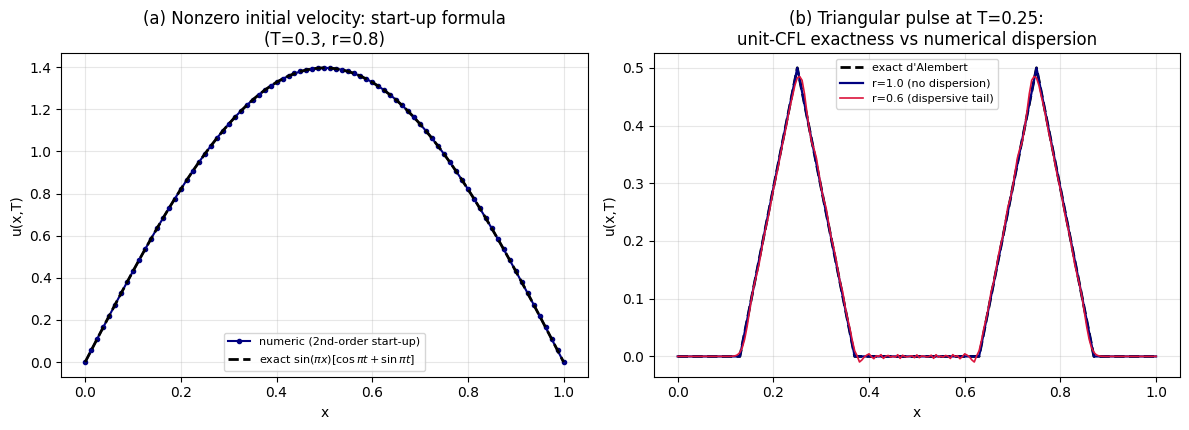

In [6]:
# --- 시각화: (좌) (a) 속도시동 해, (우) (b) r=1 vs r=0.6 펄스 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

ax[0].plot(x2, u2_2nd, "o-", ms=3, color="navy", label="numeric (2nd-order start-up)")
ax[0].plot(x2, exact_a(x2, T), "k--", lw=2, label=r"exact $\sin(\pi x)[\cos\pi t+\sin\pi t]$")
ax[0].set_xlabel("x"); ax[0].set_ylabel("u(x,T)")
ax[0].set_title("(a) Nonzero initial velocity: start-up formula\n(T=0.3, r=0.8)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(xb1, ue_b, "k--", lw=2, label="exact d'Alembert")
ax[1].plot(xb1, ub1, "-", color="navy", lw=1.6, label="r=1.0 (no dispersion)")
ax[1].plot(xb6, ub6, "-", color="crimson", lw=1.2, label="r=0.6 (dispersive tail)")
ax[1].set_xlabel("x"); ax[1].set_ylabel("u(x,T)")
ax[1].set_title("(b) Triangular pulse at T=0.25:\nunit-CFL exactness vs numerical dispersion")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 시동식의 위력**: 2차 시동식으로 푼 해는 정확해 $\sin(\pi t)\sin(\pi x)$ 와 격자점 오차
   $\sim10^{-4}$ 수준으로 일치하고, 격자를 두 배씩 세분하면 최대오차가 *4배씩* 줄어 **관측 차수 ≈ 2**.
   반면 단순 1차 시동식($u^1=u^0+\Delta t g$)은 차수가 **≈ 1** 로 주저앉는다 — 단 한 층의 시동 오차가
   이후 모든 시간층으로 전파되어 전체 정확도를 결정함을 보여준다.
2. **(b) 단위 CFL 의 마법**: $r=1$ 에서 갱신식이 $u_i^{n+1}=u_{i-1}^n+u_{i+1}^n-u_i^{n-1}$ 로 줄며
   d'Alembert 평행이동을 *대수적으로 정확히* 재현 — 비매끄러운 삼각 펄스조차 모양을 잃지 않고 좌우로
   갈라져 전파되고, 최대오차가 사실상 반올림 수준이다.
3. **$r<1$ 의 수치분산**: $r=0.6$ 에서는 펄스 뒤로 **진동 꼬리**가 생기고 정점이 약간 처진다. 이산
   분산관계 $\sin(\omega\Delta t/2)=r\sin(k\Delta x/2)$ 가 비선형이라 짧은 파장이 *느리게* 전파되기
   때문이며, 표에서 $r<1$ 의 모든 경우가 $r=1$ 의 기계정밀도 오차($\sim10^{-15}$)보다 4~5 자릿수 큰 $\sim10^{-2}$ 수준으로 뛴다(꼬리 진동의 대가).
4. **의미**: 쌍곡형에서는 단지 *안정* ($r\le1$)을 넘어, 격자를 특성곡선에 맞추는 $r=1$ 이 **정확도 면에서도
   특별**하다. 매끈한 해엔 $r$ 을 다소 줄여도 무방하지만, 불연속·급변 해(충격파류)에서는 $r$ 을 1 가까이
   두는 것이 분산 오차를 억제하는 실전 지침이 된다.

> **결론**: 첫 층 시동식의 차수가 전체 정확도를 좌우하며, 단위 CFL $r=1$ 은 leapfrog 가 d'Alembert 해를
> *정확히* 재현하는 무분산 특이점이다 — $r<1$ 은 안정하지만 수치분산(꼬리 진동)을 동반한다.

### 다음 문제 연결
- **CE 12.2.3**: $r$ 을 고정하고 격자를 세분해 leapfrog 의 **시간·공간 2차 수렴(slope 2)** 을 log-log 로
  측정하고, $r$ 별 **위상오차(분산)** 를 정량 비교해 §12.2 를 마무리한다.